## Problem 1: Sentiment Analysis Using LSTM
### Task 1: Dataset Preparation

In [61]:
import numpy as np
import pandas as pd
import re
import string
from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import imdb

np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

In [62]:
vocab_size = 10000
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=vocab_size)

print("Training samples :", len(train_data))
print("Testing  samples :", len(test_data))

all_data   = np.concatenate((train_data,   test_data),   axis=0)
all_labels = np.concatenate((train_labels, test_labels), axis=0)
print("Total samples    :", len(all_data))

Training samples : 25000
Testing  samples : 25000
Total samples    : 50000


In [63]:
MAX_PER_CLASS = 10000

pos_idx = np.where(all_labels == 1)[0][:MAX_PER_CLASS]
neg_idx = np.where(all_labels == 0)[0][:MAX_PER_CLASS]

selected = np.concatenate((pos_idx, neg_idx))
np.random.shuffle(selected)

data = all_data[selected]
labels = all_labels[selected]
print(f'Balanced dataset: {len(data)} samples  '
      f'({np.sum(labels==1)} pos / {np.sum(labels==0)} neg)')


Balanced dataset: 20000 samples  (10000 pos / 10000 neg)


In [64]:
word_index    = imdb.get_word_index()
index_to_word = {v + 3: k for k, v in word_index.items()}
index_to_word.update({0: "<PAD>", 1: "<START>", 2: "<UNK>", 3: "<UNUSED>"})

def decode_review(encoded):
    return " ".join(index_to_word.get(i, "?") for i in encoded)

texts = [decode_review(seq) for seq in data]

def preprocess(text):
    text   = text.lower()
    text   = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    tokens = text.split()
    return tokens

tokenized = [preprocess(t) for t in texts]
print("Sample tokens:", tokenized[0][:10])

Sample tokens: ['start', 'i', 'realize', 'that', 'bringing', 'a', 'novel', 'to', 'the', 'big']


In [65]:
all_words  = [w for tokens in tokenized for w in tokens]
word_counts = Counter(all_words)
most_common = word_counts.most_common(vocab_size - 2) 

word_to_idx = {"<PAD>": 0, "<UNK>": 1}
for i, (word, _) in enumerate(most_common):
    word_to_idx[word] = i + 2

idx_to_word = {idx: word for word, idx in word_to_idx.items()}
print("Vocabulary size:", len(word_to_idx))

Vocabulary size: 9908


In [66]:
def encode(tokens):
    return [word_to_idx.get(w, word_to_idx["<UNK>"]) for w in tokens]

encoded = [encode(t) for t in tokenized]
max_len = 200

def pad(seq, max_len=max_len):
    if len(seq) < max_len:
        seq = seq + [word_to_idx["<PAD>"]] * (max_len - len(seq))
    return seq[:max_len]

X = np.array([pad(s) for s in encoded])  
y = labels
print("X shape:", X.shape, "  y shape:", y.shape)

X shape: (20000, 200)   y shape: (20000,)


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", X_train.shape, "  Test:", X_test.shape)
print("Train class balance:",
      np.sum(y_train==1), "pos /", np.sum(y_train==0), "neg")

Train: (16000, 200)   Test: (4000, 200)
Train class balance: 8000 pos / 8000 neg


### Task 2: Model Training and Evaluation

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [69]:
model = Sequential([
    Embedding(vocab_size, 64),
    LSTM(32, dropout=0.2),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [70]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True, verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)


Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.5095 - loss: 0.6927 - val_accuracy: 0.5234 - val_loss: 0.6912
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.5624 - loss: 0.6822 - val_accuracy: 0.5606 - val_loss: 0.6778
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.6098 - loss: 0.7013 - val_accuracy: 0.5553 - val_loss: 0.6951
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.7016 - loss: 0.6086 - val_accuracy: 0.7006 - val_loss: 0.6070
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.7717 - loss: 0.5414 - val_accuracy: 0.7678 - val_loss: 0.5383
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.8260 - loss: 0.4597 - val_accuracy: 0.7256 - val_loss: 0.5831
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.8081 - loss: 0.4503 - val_accuracy: 0.7525 - val_loss: 0.5396
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.7623 - loss: 0.5210 - val_accu

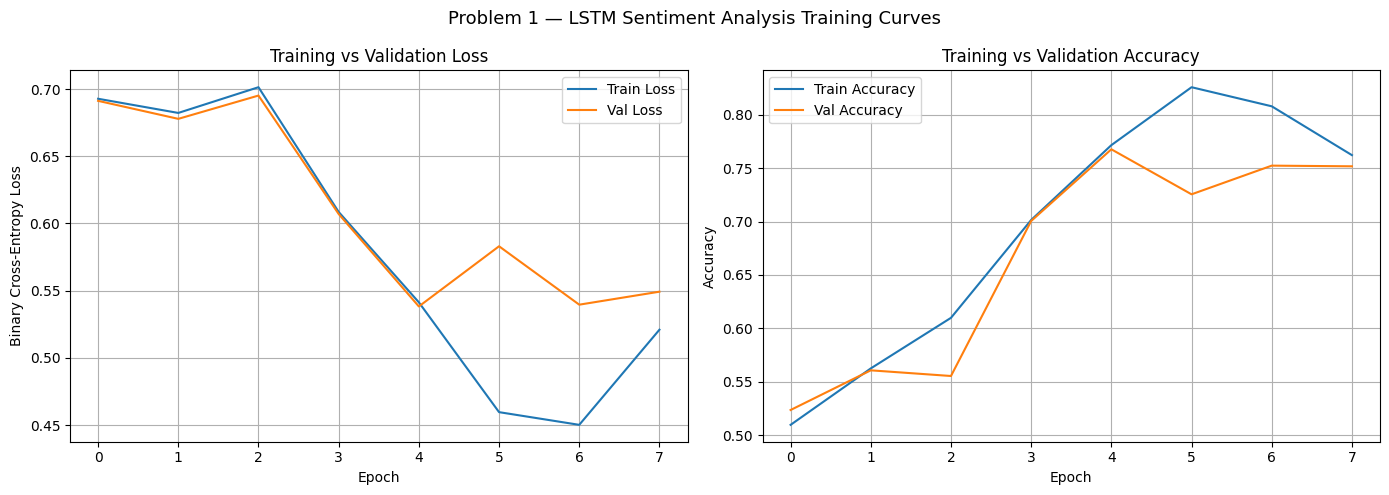

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Problem 1 — LSTM Sentiment Analysis Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7778 - loss: 0.5196

Final Test Accuracy : 0.7778
Final Test Loss     : 0.5196
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step

Confusion Matrix:
[[1564  436]
 [ 453 1547]]


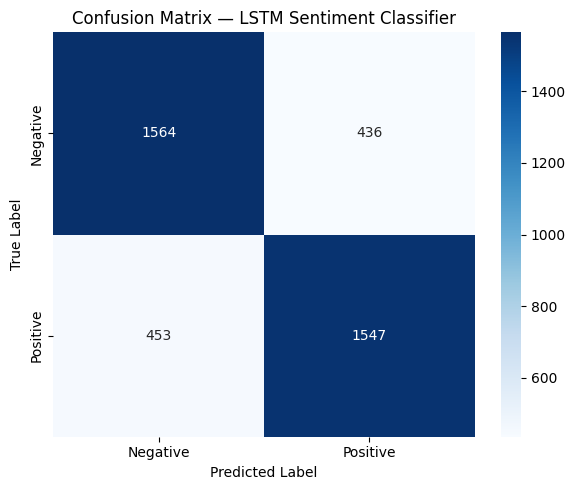

In [72]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"\nFinal Test Accuracy : {test_acc:.4f}")
print(f"Final Test Loss     : {test_loss:.4f}")

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Negative', 'Positive'],yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — LSTM Sentiment Classifier')
plt.tight_layout()
plt.show()

---
## Problem 2: Multi-Step Time-Series Forecasting Using LSTM
### Task 1: Dataset Generation

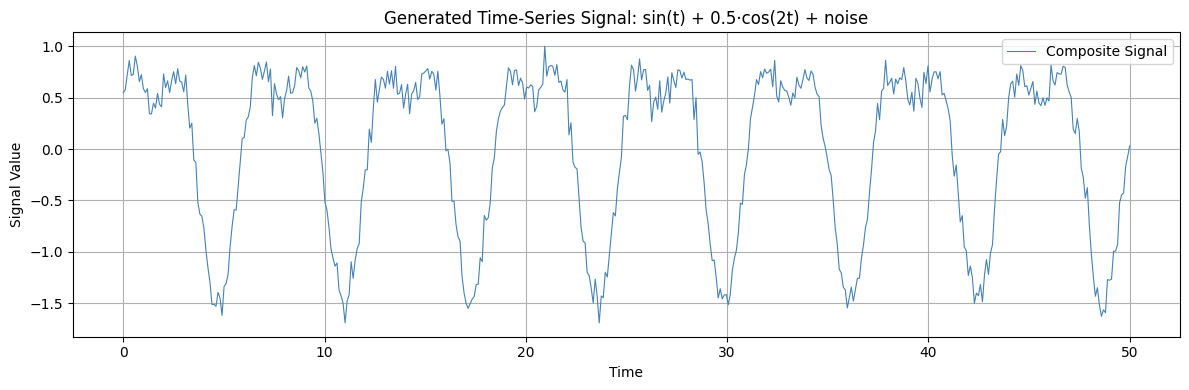

In [73]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)
t = np.linspace(0, 50, 500)
noise = np.random.normal(0, 0.1, len(t))
signal = np.sin(t) + 0.5 * np.cos(2 * t) + noise

plt.figure(figsize=(12, 4))
plt.plot(t, signal, color='steelblue', linewidth=0.8, label='Composite Signal')
plt.title('Generated Time-Series Signal: sin(t) + 0.5·cos(2t) + noise')
plt.xlabel('Time')
plt.ylabel('Signal Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Task 2: Sliding Window

In [74]:
input_len  = 50
output_len = 5

X_ts, y_ts = [], []
for i in range(len(signal) - input_len - output_len):
    X_ts.append(signal[i : i + input_len])
    y_ts.append(signal[i + input_len : i + input_len + output_len])

X_ts = np.array(X_ts, dtype=np.float32)  
y_ts = np.array(y_ts, dtype=np.float32)   

print("Window input shape :", X_ts.shape)
print("Window target shape:", y_ts.shape)
X_ts = X_ts.reshape(X_ts.shape[0], X_ts.shape[1], 1) 
print("After reshape      :", X_ts.shape)

Window input shape : (445, 50)
Window target shape: (445, 5)
After reshape      : (445, 50, 1)


In [75]:
split      = int(0.8 * len(X_ts))
X_train_ts = X_ts[:split]
X_test_ts  = X_ts[split:]
y_train_ts = y_ts[:split]
y_test_ts  = y_ts[split:]

print("Train windows:", X_train_ts.shape, "  Test windows:", X_test_ts.shape)

X_train_t = torch.tensor(X_train_ts)
y_train_t = torch.tensor(y_train_ts)
X_test_t  = torch.tensor(X_test_ts)
y_test_t  = torch.tensor(y_test_ts)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=32, shuffle=False)

Train windows: (356, 50, 1)   Test windows: (89, 50, 1)


### Task 3: Model Implementation

In [76]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=5):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2       
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)    
        out    = out[:, -1, :]  
        return self.fc(out)      

class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=5):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out    = out[:, -1, :]
        return self.fc(out)


print("LSTM parameters:", sum(p.numel() for p in LSTMModel().parameters()))
print("RNN  parameters:", sum(p.numel() for p in RNNModel().parameters()))

LSTM parameters: 50757
RNN  parameters: 12933


### Task 4: Comparison — LSTM vs Vanilla RNN

In [77]:
def train_model(model, loader, epochs=50, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses    = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(loader)
        losses.append(avg_loss)
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs}  Loss: {avg_loss:.5f}")
    return losses

torch.manual_seed(42)
rnn_model  = RNNModel()
lstm_model = LSTMModel()

print("─── Training RNN ───")
rnn_losses = train_model(rnn_model, train_loader, epochs=50)

print("\n─── Training LSTM ───")
lstm_losses = train_model(lstm_model, train_loader, epochs=50)

─── Training RNN ───
  Epoch  10/50  Loss: 0.03933
  Epoch  20/50  Loss: 0.03739
  Epoch  30/50  Loss: 0.02598
  Epoch  40/50  Loss: 0.01772
  Epoch  50/50  Loss: 0.01511

─── Training LSTM ───
  Epoch  10/50  Loss: 0.02512
  Epoch  20/50  Loss: 0.01300
  Epoch  30/50  Loss: 0.01335
  Epoch  40/50  Loss: 0.01114
  Epoch  50/50  Loss: 0.01228


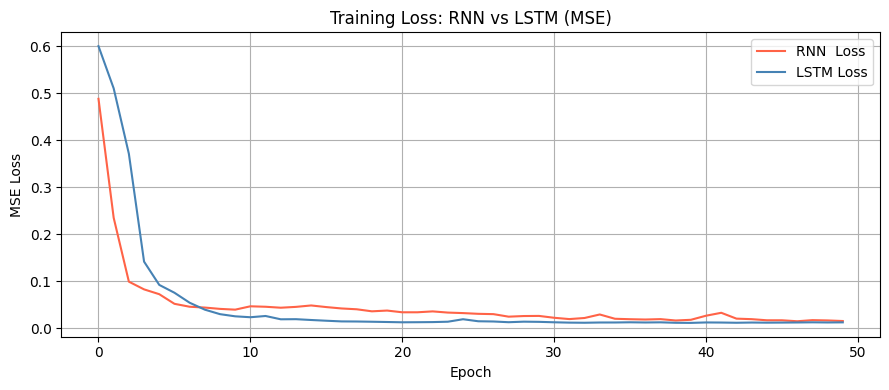

Final RNN  Train Loss : 0.01511
Final LSTM Train Loss : 0.01228


In [78]:
plt.figure(figsize=(9, 4))
plt.plot(rnn_losses,  label='RNN  Loss',  color='tomato')
plt.plot(lstm_losses, label='LSTM Loss', color='steelblue')
plt.title('Training Loss: RNN vs LSTM (MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Final RNN  Train Loss : {rnn_losses[-1]:.5f}")
print(f"Final LSTM Train Loss : {lstm_losses[-1]:.5f}")

In [79]:
criterion = nn.MSELoss()

def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    all_preds  = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            pred = model(X_batch)
            total_loss += criterion(pred, y_batch).item()
            all_preds.append(pred.numpy())
    return total_loss / len(loader), np.concatenate(all_preds, axis=0)

rnn_test_loss,  rnn_preds  = evaluate(rnn_model,  test_loader)
lstm_test_loss, lstm_preds = evaluate(lstm_model, test_loader)

print(f"RNN  Test MSE : {rnn_test_loss:.5f}")
print(f"LSTM Test MSE : {lstm_test_loss:.5f}")

RNN  Test MSE : 0.02688
LSTM Test MSE : 0.01483


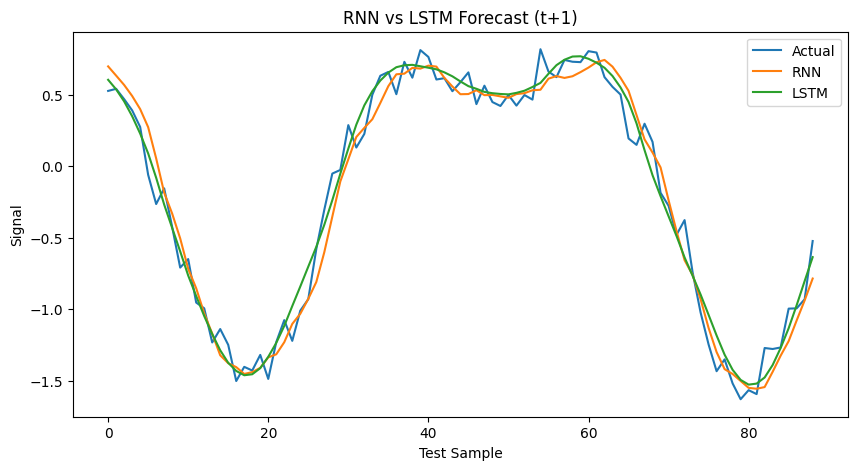

In [80]:
plt.figure(figsize=(10,5))
plt.plot(y_test_ts[:,0], label="Actual")
plt.plot(rnn_preds[:,0], label="RNN")
plt.plot(lstm_preds[:,0], label="LSTM")
plt.title("RNN vs LSTM Forecast (t+1)")
plt.xlabel("Test Sample")
plt.ylabel("Signal")
plt.legend()
plt.show()

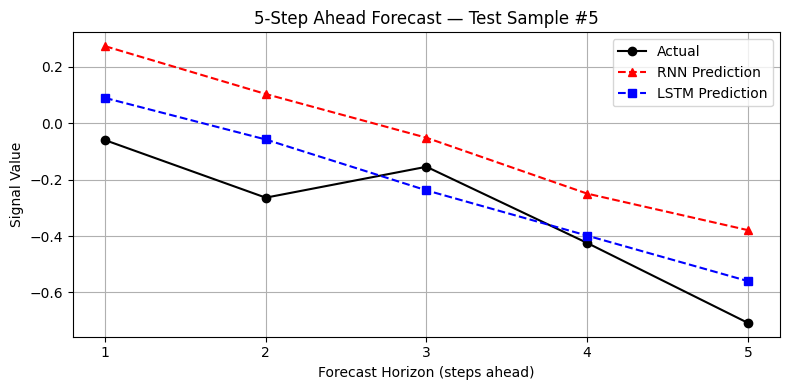

In [81]:
sample_idx = 5  

plt.figure(figsize=(8, 4))
steps = range(1, 6)
plt.plot(steps, y_test_ts[sample_idx],        'ko-',  label='Actual',        markersize=6)
plt.plot(steps, rnn_preds[sample_idx],  'r^--', label='RNN Prediction',  markersize=6)
plt.plot(steps, lstm_preds[sample_idx], 'bs--', label='LSTM Prediction', markersize=6)
plt.title(f'5-Step Ahead Forecast — Test Sample #{sample_idx}')
plt.xlabel('Forecast Horizon (steps ahead)')
plt.ylabel('Signal Value')
plt.xticks(steps)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()